# 03 - Predictive Modelling & Regression Analysis

**Input:** `student_processed.csv` (created in `01_preprocessing_eda.ipynb`)

**Tasks**
1. **Regression:** predict the final grade `G3` (0-20) with a baseline, Ordinary Least Squares, Ridge, Lasso and Random Forest models.
2. **Logistic regression:** predict whether a student passes (`G3 >= 10`) using only background and behavioural features.

**Data-leakage safeguards**
- The train/test split is the **first** step after loading; the test set is only used for the final evaluation.
- The `absences` cap and the `StandardScaler` are **fitted on the training data only**, inside a scikit-learn `Pipeline`. Cross-validation therefore refits them inside every fold.
- Hyper-parameters are tuned with cross-validation on the training set, never on the test set.
- `past_grades` (= `G1 + G2`) is excluded from the regression features because it is the exact sum of two other features (perfect multicollinearity).

## 1. Setup & Data Loading

In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, confusion_matrix,
                             accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
PASS_THRESHOLD = 10

DATA_PATH = Path("../data/student_processed.csv")

df = pd.read_csv(DATA_PATH)
assert df.isnull().sum().sum() == 0
print(f"Loaded {DATA_PATH.resolve()} - shape: {df.shape}")

Loaded A:\US\Semestr5\Szkoła Zimowa\Projekt\Repo\Data-science\data\student_processed.csv - shape: (395, 44)


### Custom transformer: leakage-safe outlier capping

`absences` has a long right tail (up to 75). A percentile cap is a *learned* parameter, so it is implemented as a transformer: the cap is estimated in `fit()` (training data) and merely applied in `transform()`.

In [3]:
class QuantileCapper(BaseEstimator, TransformerMixin):
    """Cap (winsorize) the upper tail of selected columns at a quantile learned from the training data.

    The cap is computed in fit() and applied in transform(), so test data never influences it.
    """

    def __init__(self, columns, quantile=0.95):
        self.columns = columns
        self.quantile = quantile

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.caps_ = {c: np.floor(X[c].quantile(self.quantile)) for c in self.columns}
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for c, cap in self.caps_.items():
            X[c] = X[c].clip(upper=cap)
        return X

    def get_feature_names_out(self, input_features=None):
        names = input_features if input_features is not None else self.feature_names_in_
        return np.asarray(names, dtype=object)

## 2. Train/Test Split (done before any fitting)

We split once with a fixed seed. The split is **stratified on the pass/fail label**, so the same split can be used for both the regression and the logistic-regression task and the two sets have the same pass rate.

In [4]:
y_reg = df["G3"]
y_cls = (df["G3"] >= PASS_THRESHOLD).astype(int)

# Features: everything except the target. past_grades = G1 + G2 is dropped (exact linear dependence).
FEATURES_WITH_GRADES = [c for c in df.columns if c not in ["G3", "past_grades"]]
GRADE_COLS = ["G1", "G2"]
FEATURES_NO_GRADES = [c for c in FEATURES_WITH_GRADES if c not in GRADE_COLS]

X = df[FEATURES_WITH_GRADES]
X_train, X_test, y_train, y_test, yc_train, yc_test = train_test_split(
    X, y_reg, y_cls, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cls
)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows | Features: {X.shape[1]}")
print(f"Pass rate - train: {yc_train.mean():.3f}, test: {yc_test.mean():.3f}")
print(f"Mean G3 - train: {y_train.mean():.2f}, test: {y_test.mean():.2f}")

Train: 316 rows | Test: 79 rows | Features: 42
Pass rate - train: 0.671, test: 0.671
Mean G3 - train: 10.42, test: 10.38


## 3. Preprocessing Pipeline

Continuous/ordinal-scale columns are capped (only `absences`) and standardized; binary and one-hot columns are passed through unchanged. `build_preprocessor` is applied to a given feature list, so it works for both feature scenarios.

In [5]:
CONTINUOUS_COLS = ["age", "absences", "G1", "G2", "study_to_free_ratio"]


def build_preprocessor(feature_cols):
    """Cap absences and standardize continuous columns; pass the remaining columns through."""
    cont = [c for c in CONTINUOUS_COLS if c in feature_cols]
    cont_pipe = Pipeline([
        ("cap", QuantileCapper(columns=["absences"], quantile=0.95)),
        ("scale", StandardScaler()),
    ])
    pre = ColumnTransformer([("continuous", cont_pipe, cont)], remainder="passthrough",
                            verbose_feature_names_out=False)
    pre.set_output(transform="pandas")
    return pre


def regression_metrics(y_true, y_pred):
    """MAE, RMSE and R-squared (MAPE is skipped: G3 = 0 makes percentage errors undefined)."""
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

## 4. Ordinary Least Squares (statsmodels) - Interpretation

We first fit OLS on the **training set** with all features (including the earlier grades `G1`, `G2`) to quantify the effect of each predictor. The preprocessor is fitted on the training data and only applied to the test data.

In [6]:
pre_ols = build_preprocessor(FEATURES_WITH_GRADES)
X_train_t = pre_ols.fit_transform(X_train[FEATURES_WITH_GRADES])
X_test_t = pre_ols.transform(X_test[FEATURES_WITH_GRADES])
print(f"absences cap learned on the training set: {pre_ols.named_transformers_['continuous']['cap'].caps_['absences']:.0f}")

ols = sm.OLS(y_train, sm.add_constant(X_train_t).astype(float)).fit()
print(ols.summary())

absences cap learned on the training set: 18
                            OLS Regression Results                            
Dep. Variable:                     G3   R-squared:                       0.864
Model:                            OLS   Adj. R-squared:                  0.843
Method:                 Least Squares   F-statistic:                     41.36
Date:                Thu, 08 Oct 2026   Prob (F-statistic):           2.19e-95
Time:                        22:49:54   Log-Likelihood:                -615.09
No. Observations:                 316   AIC:                             1316.
Df Residuals:                     273   BIC:                             1478.
Df Model:                          42                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

In [7]:
# Multicollinearity check (VIF > 10 is a common warning level)
Xv = sm.add_constant(X_train_t).astype(float)
vif = pd.Series([variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])], index=Xv.columns)
vif = vif.drop("const").sort_values(ascending=False)
print("Top 8 VIF values:")
vif.head(8).round(2)

Top 8 VIF values:


Fjob_other             6.57
Fjob_services          5.70
G1                     4.64
study_to_free_ratio    4.62
G2                     4.36
Mjob_teacher           3.28
Medu                   3.12
freetime               3.00
dtype: float64

In [8]:
# Significant predictors (p < 0.05)
coef_table = pd.DataFrame({"coef": ols.params, "p_value": ols.pvalues}).drop("const")
coef_table[coef_table["p_value"] < 0.05].sort_values("p_value").round(4)

,coef,p_value
G2,3.5252,0.0000
absences,0.5420,0.0000
G1,0.6994,0.0017
famrel,0.3491,0.0043
activities,-0.5433,0.0181


**Reading the OLS output:** coefficients are per one standard deviation for the standardized continuous features (`age`, `absences`, `G1`, `G2`, `study_to_free_ratio`) and per unit for the 0/1 columns. `G2` carries by far the largest effect, followed by `G1`.

**A counter-intuitive result:** `absences` has a significant *positive* coefficient. This is an artefact of the data, not a real benefit of skipping school: every student with `G3 = 0` has exactly `absences = 0` (these students most likely left the course before the final evaluation, so no absences were recorded). Compared with the other students, zero absences therefore coincides with the lowest grades.

## 5. Model Comparison with Cross-Validation

We compare five models in two scenarios:
- **With grades:** all features including `G1` and `G2` (best achievable accuracy).
- **Without grades:** background and behavioural features only (an *early-warning* setting where no grade is known yet).

Models: a mean-prediction baseline, OLS, Ridge and Lasso (regularization strength chosen by internal CV) and a Random Forest (depth and leaf size tuned by grid search). All models are `Pipeline`s, so scaling is refitted inside each CV fold.

In [9]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def make_models(feature_cols):
    pre = lambda: build_preprocessor(feature_cols)
    alphas = np.logspace(-3, 3, 40)
    return {
        "Baseline (mean)": Pipeline([("pre", pre()), ("model", DummyRegressor(strategy="mean"))]),
        "OLS": Pipeline([("pre", pre()), ("model", LinearRegression())]),
        "Ridge": Pipeline([("pre", pre()), ("model", RidgeCV(alphas=alphas))]),
        "Lasso": Pipeline([("pre", pre()), ("model", LassoCV(alphas=None, cv=5, random_state=RANDOM_STATE, max_iter=20000))]),
        "Random Forest": GridSearchCV(
            Pipeline([("pre", pre()), ("model", RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))]),
            param_grid={"model__max_depth": [3, 5, 8, None], "model__min_samples_leaf": [1, 3, 5]},
            cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1),
    }

results, fitted = [], {}
for scenario, feats in [("With grades", FEATURES_WITH_GRADES), ("Without grades", FEATURES_NO_GRADES)]:
    for name, model in make_models(feats).items():
        # Cross-validated error on the training set (for the tuned forest this is the CV of the best config)
        if name == "Random Forest":
            model.fit(X_train[feats], y_train)
            cv_rmse = -model.best_score_
            est = model.best_estimator_
        else:
            scores = cross_validate(model, X_train[feats], y_train, cv=cv, scoring="neg_root_mean_squared_error")
            cv_rmse = -scores["test_score"].mean()
            model.fit(X_train[feats], y_train)
            est = model
        pred = est.predict(X_test[feats])
        results.append({"scenario": scenario, "model": name, "CV_RMSE_train": cv_rmse,
                        **{f"test_{k}": v for k, v in regression_metrics(y_test, pred).items()}})
        fitted[(scenario, name)] = (est, feats)

results_df = pd.DataFrame(results)
results_df.round(3)

,scenario,model,CV_RMSE_train,test_MAE,test_RMSE,test_R2
0,With grades,Baseline (mean),4.578,3.322,4.482,-0.000
1,With grades,OLS,2.002,1.583,2.135,0.773
2,With grades,Ridge,1.932,1.535,2.104,0.780
3,With grades,Lasso,1.879,1.333,1.987,0.803
4,With grades,Random Forest,1.609,1.016,1.557,0.879
5,Without grades,Baseline (mean),4.578,3.322,4.482,-0.000
6,Without grades,OLS,4.316,3.686,4.633,-0.069
7,Without grades,Ridge,4.209,3.312,4.292,0.083
8,Without grades,Lasso,4.300,3.438,4.417,0.028
9,Without grades,Random Forest,3.900,3.010,3.937,0.228


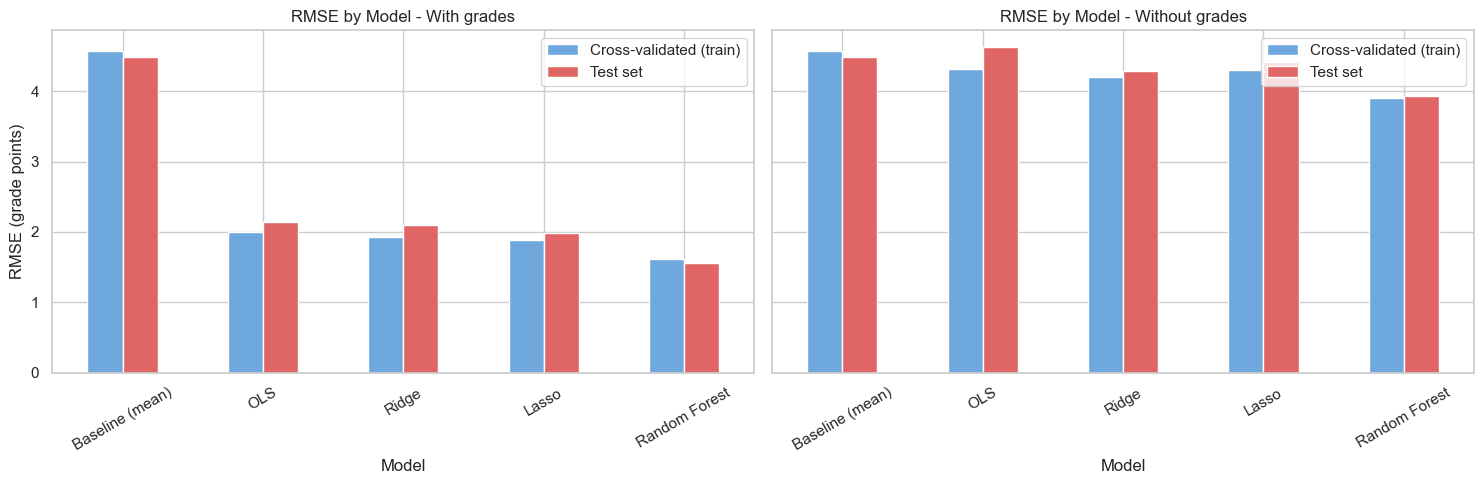

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, scenario in zip(axes, ["With grades", "Without grades"]):
    sub = results_df[results_df["scenario"] == scenario].set_index("model")
    sub[["CV_RMSE_train", "test_RMSE"]].plot(kind="bar", ax=ax, color=["#6fa8dc", "#e06666"])
    ax.set_title(f"RMSE by Model - {scenario}")
    ax.set_xlabel("Model")
    ax.set_ylabel("RMSE (grade points)")
    ax.legend(["Cross-validated (train)", "Test set"])
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

**Takeaways:**
- With `G1` and `G2` available, all models beat the mean baseline by a wide margin. Regularization helps a little (Lasso and Ridge have a lower test RMSE than plain OLS), and the **Random Forest is clearly the best** (test RMSE about 1.6 vs about 2.1 for OLS), which suggests non-linear effects, such as the `G3 = 0` group, that a linear model cannot capture.
- Without earlier grades, no model explains much variance: OLS is no better than the baseline and the best model (Random Forest) reaches a test R-squared of only about 0.2. Background and lifestyle features alone are weak predictors of the final grade.

## 6. Diagnostics of the Best Model (With Grades)

Best model by cross-validated RMSE: Random Forest


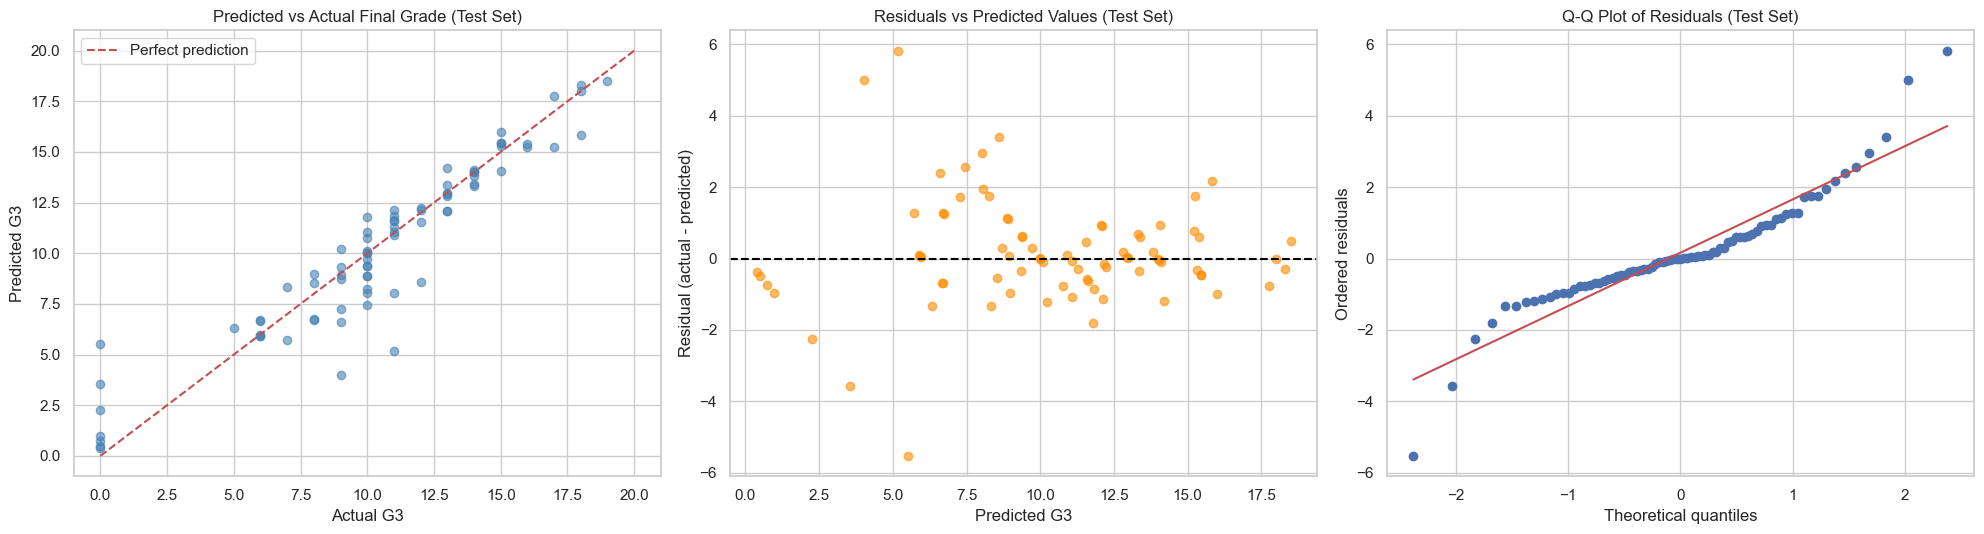

In [11]:
with_grades = results_df[results_df["scenario"] == "With grades"].set_index("model")
best_name = with_grades["CV_RMSE_train"].idxmin()   # chosen by cross-validation, not by the test set
best_est, best_feats = fitted[("With grades", best_name)]
y_pred = best_est.predict(X_test[best_feats])
resid = y_test - y_pred
print(f"Best model by cross-validated RMSE: {best_name}")

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

axes[0].scatter(y_test, y_pred, alpha=0.6, color="steelblue")
axes[0].plot([0, 20], [0, 20], "r--", label="Perfect prediction")
axes[0].set_title("Predicted vs Actual Final Grade (Test Set)")
axes[0].set_xlabel("Actual G3")
axes[0].set_ylabel("Predicted G3")
axes[0].legend()

axes[1].scatter(y_pred, resid, alpha=0.6, color="darkorange")
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_title("Residuals vs Predicted Values (Test Set)")
axes[1].set_xlabel("Predicted G3")
axes[1].set_ylabel("Residual (actual - predicted)")

stats.probplot(resid, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot of Residuals (Test Set)")
axes[2].set_xlabel("Theoretical quantiles")
axes[2].set_ylabel("Ordered residuals")

plt.tight_layout()
plt.show()

In [12]:
# Effect of the G3 = 0 students (probable dropouts) on the test error
mask_nonzero = y_test > 0
m_all = regression_metrics(y_test, y_pred)
m_nz = regression_metrics(y_test[mask_nonzero], y_pred[mask_nonzero])
pd.DataFrame({"all test students": m_all, "test students with G3 > 0": m_nz}).T.round(3)

,MAE,RMSE,R2
all test students,1.016,1.557,0.879
test students with G3 > 0,0.922,1.401,0.814


Students with `G3 = 0` (who had non-zero `G1`/`G2`) are the hardest cases: a model cannot easily anticipate that a student will skip the final evaluation. Excluding them lowers the test error (table above) but does not remove it, so the group explains part, not all, of the remaining error.

## 7. Feature Importance

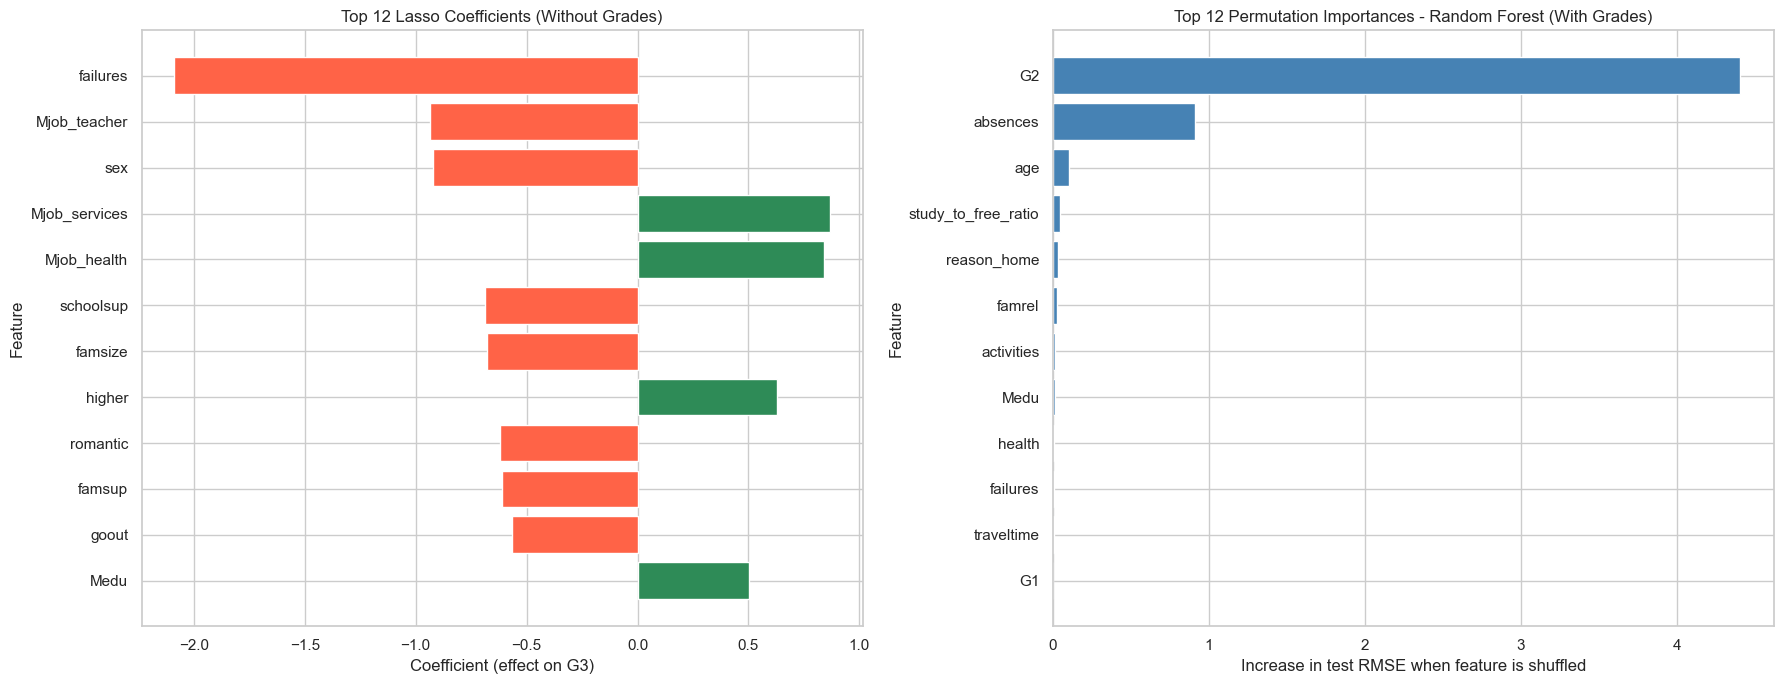

In [13]:
# Lasso coefficients (grade-free scenario) and permutation importance of the Random Forest (with grades)
lasso_est, lasso_feats = fitted[("Without grades", "Lasso")]
lasso_coefs = pd.Series(lasso_est.named_steps["model"].coef_,
                        index=lasso_est.named_steps["pre"].get_feature_names_out()).sort_values(key=np.abs, ascending=False)

rf_est, rf_feats = fitted[("With grades", "Random Forest")]
perm = permutation_importance(rf_est, X_test[rf_feats], y_test, n_repeats=20, random_state=RANDOM_STATE,
                              scoring="neg_root_mean_squared_error")
perm_imp = pd.Series(perm.importances_mean, index=rf_feats).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
top_l = lasso_coefs.head(12).iloc[::-1]
axes[0].barh(top_l.index, top_l.values, color=["tomato" if v < 0 else "seagreen" for v in top_l])
axes[0].set_title("Top 12 Lasso Coefficients (Without Grades)")
axes[0].set_xlabel("Coefficient (effect on G3)")
axes[0].set_ylabel("Feature")

top_p = perm_imp.head(12).iloc[::-1]
axes[1].barh(top_p.index, top_p.values, color="steelblue")
axes[1].set_title("Top 12 Permutation Importances - Random Forest (With Grades)")
axes[1].set_xlabel("Increase in test RMSE when feature is shuffled")
axes[1].set_ylabel("Feature")
plt.tight_layout()
plt.show()

### 7.1 Sample predictions

In [14]:
sample = X_test.iloc[:8]
demo = pd.DataFrame({
    "actual_G3": y_test.iloc[:8].values,
    "predicted_G3": best_est.predict(sample[best_feats]).round(2),
})
demo["absolute_error"] = (demo["actual_G3"] - demo["predicted_G3"]).abs().round(2)
demo

,actual_G3,predicted_G3,absolute_error
0,12,12.16,0.16
1,7,8.32,1.32
2,12,12.25,0.25
3,10,11.07,1.07
4,17,17.78,0.78
5,14,13.31,0.69
6,15,14.07,0.93
7,8,8.54,0.54


## 8. Logistic Regression: Predicting Pass / Fail

**Target:** `passed = 1` if `G3 >= 10`, else `0`.

To measure how much *background and behaviour* alone say about success, we **exclude `G1` and `G2`** from the features. The model is fitted on the training split; the preprocessor (cap + scaler) is again fitted on the training data only.

In [15]:
pre_log = build_preprocessor(FEATURES_NO_GRADES)
Xc_train = pre_log.fit_transform(X_train[FEATURES_NO_GRADES])
Xc_test = pre_log.transform(X_test[FEATURES_NO_GRADES])

logit = sm.Logit(yc_train, sm.add_constant(Xc_train).astype(float)).fit(disp=False, maxiter=200)
print(logit.summary())

                           Logit Regression Results                           
Dep. Variable:                     G3   No. Observations:                  316
Model:                          Logit   Df Residuals:                      275
Method:                           MLE   Df Model:                           40
Date:                Thu, 08 Oct 2026   Pseudo R-squ.:                  0.2579
Time:                        22:52:03   Log-Likelihood:                -148.56
converged:                       True   LL-Null:                       -200.20
Covariance Type:            nonrobust   LLR p-value:                 1.686e-07
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   2.7760      1.823      1.523      0.128      -0.797       6.349
age                    -0.2040      0.202     -1.010      0.313      -0.600       0.192
absences        

In [16]:
# Odds ratios of the significant predictors (p < 0.05)
odds = pd.DataFrame({"odds_ratio": np.exp(logit.params), "p_value": logit.pvalues,
                     "ci_low": np.exp(logit.conf_int()[0]), "ci_high": np.exp(logit.conf_int()[1])}).drop("const")
odds[odds["p_value"] < 0.05].sort_values("p_value").round(4)

,odds_ratio,p_value,ci_low,ci_high
failures,0.2515,0.0000,0.1443,0.4381
goout,0.6253,0.0038,0.4550,0.8593
schoolsup,0.3228,0.0118,0.1338,0.7787
Walc,1.4856,0.0327,1.0332,2.1361


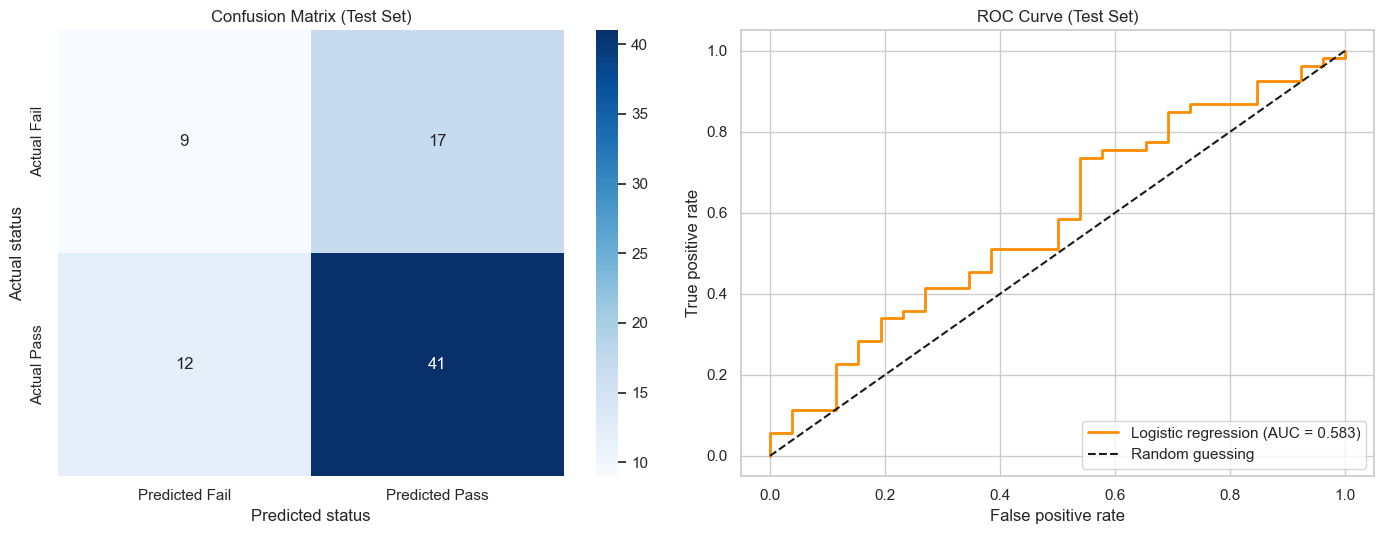

=== Test-set classification metrics ===
Accuracy  : 0.6329
Precision : 0.7069
Recall    : 0.7736
F1-score  : 0.7387
ROC-AUC   : 0.5827

Majority-class baseline accuracy: 0.6709


In [17]:
# Evaluation on the untouched test set
y_prob = logit.predict(sm.add_constant(Xc_test, has_constant="add").astype(float))
y_hat = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(yc_test, y_hat)
metrics = {
    "Accuracy": accuracy_score(yc_test, y_hat),
    "Precision": precision_score(yc_test, y_hat),
    "Recall": recall_score(yc_test, y_hat),
    "F1-score": f1_score(yc_test, y_hat),
    "ROC-AUC": roc_auc_score(yc_test, y_prob),
}
majority_acc = max(yc_test.mean(), 1 - yc_test.mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Predicted Fail", "Predicted Pass"], yticklabels=["Actual Fail", "Actual Pass"])
axes[0].set_title("Confusion Matrix (Test Set)")
axes[0].set_xlabel("Predicted status")
axes[0].set_ylabel("Actual status")

fpr, tpr, _ = roc_curve(yc_test, y_prob)
axes[1].plot(fpr, tpr, color="darkorange", lw=2, label=f"Logistic regression (AUC = {metrics['ROC-AUC']:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", label="Random guessing")
axes[1].set_title("ROC Curve (Test Set)")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].legend(loc="lower right")
plt.tight_layout()
plt.show()

print("=== Test-set classification metrics ===")
for k, v in metrics.items():
    print(f"{k:10s}: {v:.4f}")
print(f"\nMajority-class baseline accuracy: {majority_acc:.4f}")

In [18]:
demo_cls = pd.DataFrame({
    "actual": yc_test.iloc[:8].map({1: "Pass", 0: "Fail"}).values,
    "probability_pass": y_prob.iloc[:8].round(3).values,
    "predicted": y_hat.iloc[:8].map({1: "Pass", 0: "Fail"}).values,
})
demo_cls

,actual,probability_pass,predicted
0,Pass,0.294,Fail
1,Fail,0.129,Fail
2,Pass,0.565,Pass
3,Pass,0.870,Pass
4,Pass,0.957,Pass
5,Pass,0.815,Pass
6,Pass,0.821,Pass
7,Fail,0.063,Fail


**Interpretation:** on the test set this unregularized model is **not better than always predicting "pass"** (accuracy is below the majority-class baseline and the ROC-AUC is only about 0.58). With 40 predictors and only 316 training rows it overfits: the training fit is decent (pseudo R-squared of about 0.26), but most coefficients are not significant. The significant predictors are `failures` (strongest; each additional past failure cuts the odds of passing by roughly 75%), `goout`, `schoolsup` and `Walc`.

Next we check whether a *regularized* logistic regression, tuned by cross-validation on the training set, does better.

In [19]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
logit_cv = Pipeline([
    ("pre", build_preprocessor(FEATURES_NO_GRADES)),
    ("model", LogisticRegressionCV(Cs=np.logspace(-3, 2, 30), cv=skf, penalty="l2", scoring="roc_auc",
                                   max_iter=5000, random_state=RANDOM_STATE)),
])
logit_cv.fit(X_train[FEATURES_NO_GRADES], yc_train)

prob_cv = logit_cv.predict_proba(X_test[FEATURES_NO_GRADES])[:, 1]
pred_cv = (prob_cv >= 0.5).astype(int)

comparison = pd.DataFrame({
    "Majority-class baseline": {"Accuracy": majority_acc, "ROC-AUC": 0.5},
    "Logistic (unregularized, statsmodels)": {"Accuracy": metrics["Accuracy"], "ROC-AUC": metrics["ROC-AUC"]},
    "Logistic (L2, CV-tuned)": {"Accuracy": accuracy_score(yc_test, pred_cv), "ROC-AUC": roc_auc_score(yc_test, prob_cv)},
}).T
print(f"Selected regularization strength C = {logit_cv.named_steps['model'].C_[0]:.4f}")
comparison.round(3)

Selected regularization strength C = 0.3857


,Accuracy,ROC-AUC
Majority-class baseline,0.671,0.500
"Logistic (unregularized, statsmodels)",0.633,0.583
"Logistic (L2, CV-tuned)",0.684,0.606


Compare the three rows above: regularization is the appropriate remedy when there are many weak predictors and few observations. Whether it also beats the baseline accuracy on this small test set (79 students) should be read cautiously, since a single split gives noisy estimates. Decision-tree classifiers for the same task are built in `04_classification.ipynb`.

## 9. Summary

In [20]:
print("Regression (test set):")
display(results_df.set_index(["scenario", "model"])[["test_MAE", "test_RMSE", "test_R2"]].round(3))
print("Logistic regression without prior grades (test set):")
display(pd.Series(metrics).round(3).to_frame("value").T)

Regression (test set):


test_MAE  test_RMSE  test_R2
scenario       model                                        
With grades    Baseline (mean)     3.322      4.482   -0.000
               OLS                 1.583      2.135    0.773
               Ridge               1.535      2.104    0.780
               Lasso               1.333      1.987    0.803
               Random Forest       1.016      1.557    0.879
Without grades Baseline (mean)     3.322      4.482   -0.000
               OLS                 3.686      4.633   -0.069
               Ridge               3.312      4.292    0.083
               Lasso               3.438      4.417    0.028
               Random Forest       3.010      3.937    0.228

Logistic regression without prior grades (test set):


,Accuracy,Precision,Recall,F1-score,ROC-AUC
value,0.633,0.707,0.774,0.739,0.583


**Conclusions**
- Earlier grades (`G1`, `G2`), above all `G2`, are by far the best predictors of `G3`.
- Without earlier grades, predictive power is weak (low R-squared, and logistic regression close to the majority-class baseline), so lifestyle and background features should not be over-interpreted.
- The Random Forest clearly outperforms the linear models when grades are available, pointing to non-linear structure in the data.
- The `G3 = 0` students (probable dropouts, all with zero recorded absences) distort the linear models, including the sign of the `absences` coefficient; a separate dropout model, or excluding them, would give a cleaner picture.